In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor 
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder

In [18]:
X_train = pd.read_csv("../data/challenge_train_features.csv", index_col=0)
y_train = pd.read_csv("../data/challenge_train_revenue.csv", index_col=0)
X_test = pd.read_csv("../data/challenge_test_features.csv", index_col=0)

,revenue
12,48482
94,33579813
157,5000000
239,100
345,25
735,193355800
786,34659
787,4
837,1
987,99000


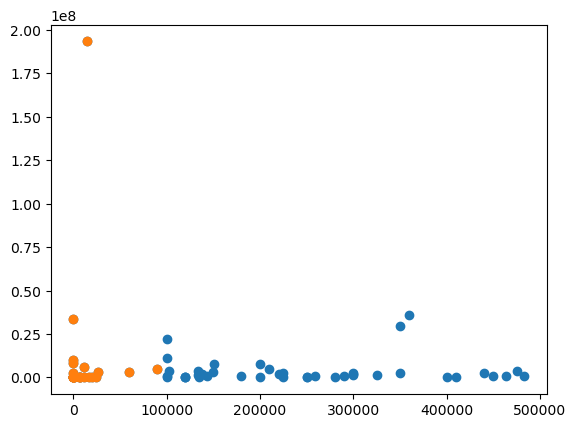

In [39]:

   
X_train["budget_nonzero"] = X_train["budget"].replace(0, np.nan)
X_test["budget_nonzero"] = X_test["budget"].replace(0, np.nan)

#afficher le budget_nonzero avec le revenu (ytrain)
import matplotlib.pyplot as plt
# plt.scatter(X_train["budget_nonzero"], y_train)
#afficher pour les budget < 2e6
# plt.scatter(X_train[X_train["budget_nonzero"]<1e6]["budget_nonzero"], y_train[X_train["budget_nonzero"]<1e6])


#afficher pour les budget < 500000
plt.scatter(X_train[X_train["budget_nonzero"]<5e5]["budget_nonzero"], y_train[X_train["budget_nonzero"]<5e5])


#afficher pour les budget < 100000
plt.scatter(X_train[X_train["budget_nonzero"]<1e5]["budget_nonzero"], y_train[X_train["budget_nonzero"]<1e5])


X_train[X_train["budget_nonzero"]<1e5]["budget_nonzero"].describe()
y_train[X_train["budget_nonzero"]<1e5]

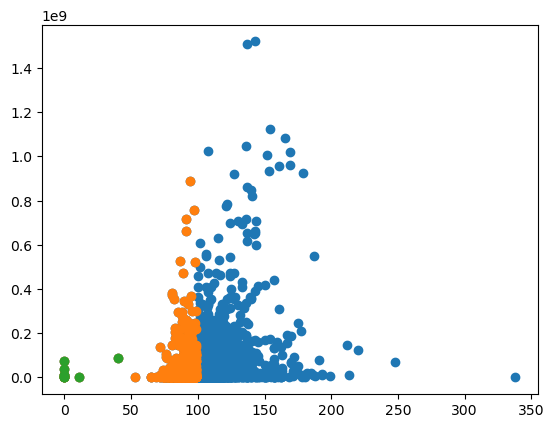

In [ ]:
#afficher length avec le revenu des films
plt.scatter(X_train["length"], y_train)

#afficher pour les length < 100
plt.scatter(X_train[X_train["length"]<100]["length"], y_train[X_train["length"]<100])

#afficher pour les legth < 50
plt.scatter(X_train[X_train["length"]<50]["length"], y_train[X_train["length"]<50])


#supprimer les outliers avec les length <50
X_train = X_train[X_train["length"]>=50]
y_train = y_train[X_train["length"]>=50]

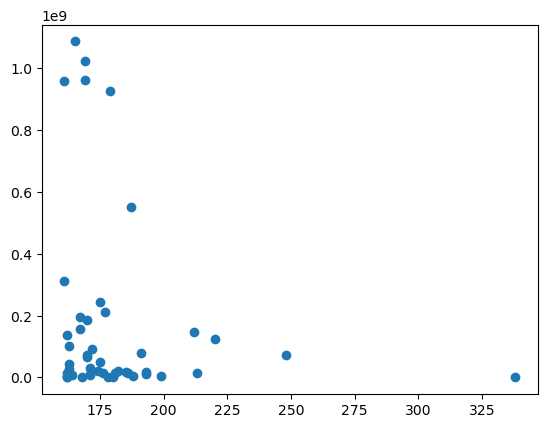

In [34]:
#affichier pour les legnth > 200
plt.scatter(X_train[X_train["length"]>160]["length"], y_train[X_train["length"]>160])

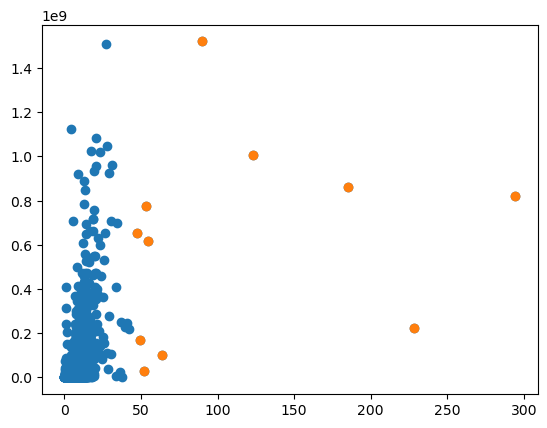

In [51]:
#afficher la popularity_score avec le revenu
plt.scatter(X_train["popularity_score"], y_train)

#afficher pour les popularity_score >45
plt.scatter(X_train[X_train["popularity_score"]>45]["popularity_score"], y_train[X_train["popularity_score"]>45])



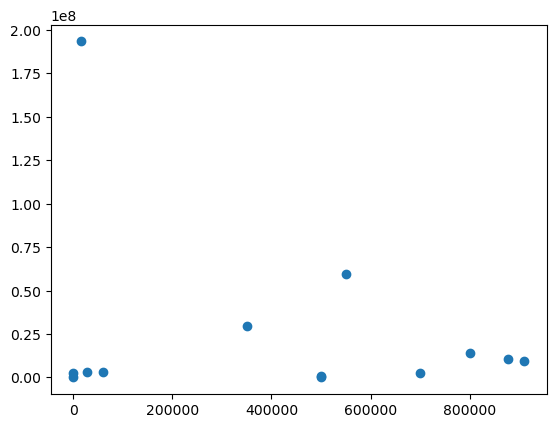

In [48]:
#graphique pour le budget
plt.scatter(X_train[(X_train["popularity_score"]>10) & (X_train["budget_nonzero"]<1e6)]["budget_nonzero"], y_train[(X_train["popularity_score"]>10) & (X_train["budget_nonzero"]<1e6)])

In [4]:
def get_first_genre(X):
    """
    Extrait le premier genre de la liste des genres (séparés par des virgules)
    Example: 'Action, Adventure, Drama' -> 'Action'
    """
    X = X.copy()
    # Divise la chaîne par les virgules et prend le premier élément
    X['genre'] = X['genre'].str.split(',').str[0]
    # Gestion des valeurs manquantes
    X['genre'] = X['genre'].fillna('Unknown')
    return X[['genre']]

In [5]:
X_train["first_genre"] = get_first_genre(X_train)
get_first_genre(X_train)['genre'].value_counts()

genre
Drama              531
Comedy             407
Action             333
Adventure          122
Horror             117
Crime              100
Thriller            83
Documentary         52
Animation           50
Romance             44
Fantasy             39
Family              25
Science Fiction     25
Mystery             23
Music               14
War                 13
Western              8
History              7
Unknown              5
Foreign              2
Name: count, dtype: int64

In [6]:
df = X_train.join(y_train)

In [7]:
# Moyenne globale du revenu
moyenne_globale = df["revenue"].mean()

# Moyenne par catégorie
revenu_par_genre = df.groupby("first_genre")["revenue"].mean()

# Pourcentage d'écart par rapport à la moyenne globale
pourcentage_ecart = (revenu_par_genre / moyenne_globale - 1) * 100

# Résumé clair
resultat = pd.DataFrame({
    "revenu_moyen": revenu_par_genre,
    "écart_%_par_rapport_moyenne": pourcentage_ecart
})

print(resultat)


                 revenu_moyen  écart_%_par_rapport_moyenne
first_genre                                               
Action           9.835564e+07                    47.168954
Adventure        1.947422e+08                   191.391585
Animation        1.755856e+08                   162.727655
Comedy           4.933886e+07                   -26.174563
Crime            3.621618e+07                   -45.809951
Documentary      4.473137e+06                   -93.306872
Drama            3.611863e+07                   -45.955910
Family           1.169509e+08                    74.992866
Fantasy          9.895940e+07                    48.072362
Foreign          1.406500e+05                   -99.789546
History          4.113461e+07                   -38.450531
Horror           4.663436e+07                   -30.221281
Music            3.254449e+07                   -51.303868
Mystery          4.303593e+07                   -35.605592
Romance          4.913550e+07                   -26.4788

stats du revenus pour les budgets <= 20 000
count           561
mean     11,663,543
std      24,764,233
min               1
25%         206,728
50%       2,003,822
75%      11,472,454
max     239,606,210
Name: revenue, dtype: float64


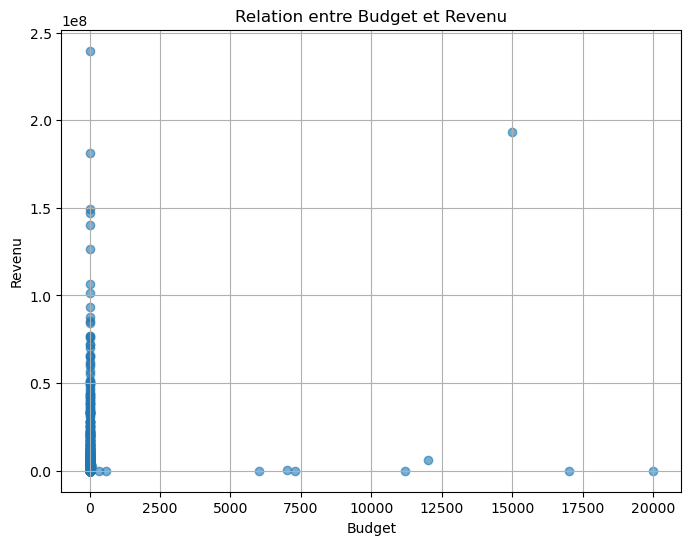

stats pour les budgets > 100 millions
count              79
mean      501,242,139
std       327,360,376
min        48,668,907
25%       262,011,116
50%       408,579,038
75%       702,211,580
max     1,519,557,910
Name: revenue, dtype: float64
count            79
mean    158,639,241
std      51,595,688
min     102,000,000
25%     120,000,000
50%     149,000,000
75%     185,000,000
max     380,000,000
Name: budget, dtype: float64


<Figure size 640x480 with 0 Axes>

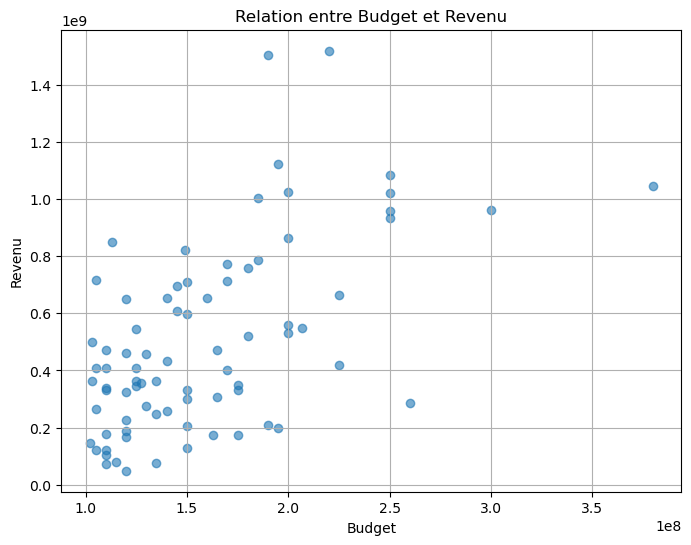

In [8]:
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:,.0f}'.format)

#garder les budget entre 0 et 100000
df_temp = df[df['budget'] <= 20000]
print("stats du revenus pour les budgets <= 20 000")
print(df_temp["revenue"].describe())
plt.figure(figsize=(8,6))
plt.scatter(df_temp['budget'], df_temp['revenue'], alpha=0.6)
plt.xlabel('Budget')
plt.ylabel('Revenu')
plt.title('Relation entre Budget et Revenu')
plt.grid(True)
plt.show()


print("stats pour les budgets > 100 millions")
df_temp2 = df[df['budget'] > 100000000].copy()
print(df_temp2["revenue"].describe())



plt.clf() 
print(df_temp2["budget"].describe())
fig = plt.figure(figsize=(8,6))
plt.scatter(df_temp2['budget'], df_temp2['revenue'], alpha=0.6)
plt.xlabel('Budget')
plt.ylabel('Revenu')
plt.title('Relation entre Budget et Revenu')
plt.grid(True)
plt.show()


In [9]:
#creer un df en retirant les budgets nuls
df_nonzero_budget = df[df['budget'] > 0].copy()

# Moyenne globale du revenu
moyenne_globale = df_nonzero_budget["revenue"].mean()

# Moyenne par catégorie
revenu_par_genre = df_nonzero_budget.groupby("first_genre")["revenue"].mean()

#compte par catégorie
compte_par_genre = df_nonzero_budget['first_genre'].value_counts()

# Pourcentage d'écart par rapport à la moyenne globale
pourcentage_ecart = (revenu_par_genre / moyenne_globale - 1) * 100

# Résumé clair
resultat = pd.DataFrame({
    "revenu_moyen": revenu_par_genre,
    "écart_%_par_rapport_moyenne": pourcentage_ecart,"compte": compte_par_genre
})

resultat = resultat.sort_values(by="écart_%_par_rapport_moyenne", ascending=False)

print(resultat)

                 revenu_moyen  écart_%_par_rapport_moyenne  compte
first_genre                                                       
Animation         221,636,823                          154      39
Adventure         213,494,628                          144     109
Family            180,192,368                          106      15
Science Fiction   172,083,737                           97      23
Fantasy           126,803,444                           45      29
Action            115,986,662                           33     273
Thriller           74,864,532                          -14      60
Comedy             66,390,306                          -24     275
Romance            57,464,632                          -34      34
Horror             53,966,038                          -38     100
Drama              49,534,072                          -43     359
History            47,956,411                          -45       6
Mystery            45,549,288                          -48    

In [10]:
df = X_train.join(y_train)
df["genres_list"] = df["genre"].apply(lambda x: x.split(",") if isinstance(x, str) else [])


test_genre_counts = df["genres_list"].explode().value_counts()
print(test_genre_counts)



genres_list
Drama              1009
Comedy              692
Thriller            511
Action              477
Romance             364
Crime               308
Adventure           288
Horror              199
Science Fiction     181
Family              180
Fantasy             151
Mystery             132
Animation            94
History              81
Music                72
War                  65
Documentary          63
Western              28
Foreign              22
Name: count, dtype: int64


In [11]:
X_train = pd.read_csv("../data/challenge_train_features.csv", index_col=0)

df = X_train.copy()

df["country"].value_counts()




country
US             1195
GB,US            75
GB               57
IN               46
CA,US            33
               ... 
GB,DE             1
IN,CH             1
CN,US,KR,HK       1
FR,JP,GB,US       1
GB,IT,FR,TN       1
Name: count, Length: 236, dtype: int64

In [12]:
countries_list = df["country"].str.split().explode()
unique_countries = countries_list.value_counts()
print(unique_countries)

# Ou pour avoir juste la liste des pays uniques sans comptage
print(countries_list.unique())

country
US             1195
GB,US            75
GB               57
IN               46
CA,US            33
               ... 
GB,DE             1
IN,CH             1
CN,US,KR,HK       1
FR,JP,GB,US       1
GB,IT,FR,TN       1
Name: count, Length: 236, dtype: int64
['US' 'GB,US' 'GB' 'CA' nan 'IN' 'DK,SE' 'IT' 'RU' 'FR' 'TR,US' 'FR,DE,GB'
 'DE,GB,JP,US' 'ES' 'CA,FR' 'US,CA' 'GB,US,CH' 'AU,GB,US' 'IT,FR' 'BS,US'
 'CA,FR,GB' 'CA,US' 'IT,US' 'US,AR,CL,FR,ES' 'FR,US' 'DE,JP,US' 'KR'
 'FR,CR,ES,GB,US' 'IL,US' 'US,GB,DE' 'BE' 'FR,GB' 'CN,HK' 'CA,ES' 'HK,US'
 'JP' 'BR,US' 'AU' 'BE,FR' 'US,DE,BE' 'CA,DE' 'DE,US' 'NL,BE' 'SE'
 'DE,GB,US' 'AU,HK,RU,US' 'ID' 'CA,FR,US' 'US,ES' 'FR,DE' 'FR,ES' 'CN,US'
 'IE,GB' 'RO' 'DE,NL,US' 'FI' 'CN,FR,HK' 'HK' 'FR,NO,PL' 'AT,DE' 'AU,US'
 'US,ZA' 'US,IN' 'BF,DE,GH,GB,US' 'DE,IE,GB,US' 'FR,IT' 'CA,DE,US'
 'IT,ES,DE' 'MX' 'DK' 'ES,FR' 'GB,FR,US,RO' 'IN,FR,DE' 'CA,RU,US' 'IT,GB'
 'SG' 'FR,IS,GB,US' 'DE' 'IR' 'GR,US' 'DE,US,GB' 'IS,US,GB' 'NZ,AU,FR'
 'AT,HU' 'BR,GB

In [14]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error

CHOOSEN_MODEL = "catboost"  # "catboost", "xgboost", "histgradientboosting"
ALL_MODELS = True

# ----------------------------------------------------------------
# Preprocessing functions
# ----------------------------------------------------------------

# Preprocessing functions


# Clip popularity scores at 20
def clip_popularity(X):
    X = X.copy()
    X["popularity_score"] = X["popularity_score"].clip(upper=20)
    return X


# Create a binary indicator for zero budget (nan values)
def budget_missing_indicator(X):
    X = X.copy()
    X["budget_is_zero"] = (X["budget"] == 0).astype(int)
    return X


def log_budget(X):
    X = X.copy()
    X["budget"] = np.log1p(X["budget"].clip(lower=0))
    return X


def log_popularity(X):
    X = X.copy()
    X["popularity_score"] = np.log1p(X["popularity_score"].clip(lower=0))
    return X


def budget_0_to_nan(X):
    X = X.copy()
    X["budget_nonzero"] = X["budget"].replace(0, np.nan)
    return X


def collection_to_binary(X):
    X = X.copy()
    X["has_collection"] = X["collection"].notna().astype(int)
    return X


def english_to_binary(X):
    """
    Convert language column to binary (0/1) where:
    1 = movie is in English ('en')
    0 = movie is in another language
    """
    X = X.copy()
    X["language"] = (X["language"] == "en").astype(int)
    return X


def US_to_binary(X):
    """
    Convert country column to binary (0/1) where:
    1 = movie is from US
    0 = movie is from another country
    """
    X = X.copy()
    X["country_US"] = (X["country"] == "US").astype(int)
    return X


def count_countries(X):
    """create a column 'country_count' that counts the number of countries listed
    in the 'country' column.
    """
    X = X.copy()
    X["country_count"] = (
        X["country"]
        .fillna("")
        .apply(lambda val: len(str(val).split(",")) if str(val).strip() != "" else 0)
    )
    return X


def get_main_countries(X, top_n=7):
    """
    Renvoie les top N pays principaux les plus fréquents.
    Le pays principal est le premier dans la chaîne 'country' avant la virgule.
    """
    # Extraire pays principal
    country_main = (
        X["country"]
        .apply(lambda x: x.split(",")[0] if isinstance(x, str) else "Unknown")
        .astype(str)
        .str.strip()
    )
    top_countries = country_main.value_counts().nlargest(top_n).index.tolist()

    return top_countries


def add_country_dummies(X, top_countries):
    """
    Crée des dummies pour les pays principaux présents dans top_countries.
    Les pays non présents sont regroupés en 'Other'.
    """
    X = X.copy()
    X["country_main"] = (
        X["country"]
        .apply(lambda x: x.split(",")[0] if isinstance(x, str) else "Unknown")
        .astype(str)
        .str.strip()
    )

    # mettre les autres pays à 'Other'
    X["country_main"] = X["country_main"].apply(
        lambda c: c if c in top_countries else "Other"
    )
    dummies = pd.get_dummies(X["country_main"], prefix="country", dtype=int)
    X = pd.concat([X, dummies], axis=1)

    return X, list(dummies.columns)


def add_top_company_features(X, top_revenue_companies):
    """
    Ajoute deux colonnes :
    - 'num_top_companies' : nombre de studios du film présents dans la liste top_revenue_companies
    - 'is_top_company' : 1 si au moins un studio du film est dans la liste, sinon 0
    """
    X = X.copy()

    def count_star_companies(company_str):
        if not isinstance(company_str, str) or company_str.strip() == "":
            return 0
        companies = [c.strip() for c in company_str.split(",")]
        return sum(c in top_revenue_companies for c in companies)

    # Nombre de studios prestigieux dans chaque film
    X["num_top_companies"] = X["company"].fillna("").apply(count_star_companies)

    # Variable binaire si au moins un studio prestigieux
    X["is_top_company"] = (X["num_top_companies"] > 0).astype(int)

    return X


def get_frequent_genres(X, min_occurrence=150):
    """
    Get list of genres that appear more than min_occurrence times
    return a list of frequent genres + "Other"
    """
    X = X.copy()
    X["genres_list"] = X["genre"].apply(
        lambda x: x.split(",") if isinstance(x, str) else []
    )
    genre_counts = X["genres_list"].explode().value_counts()
    selected_genres = genre_counts[genre_counts >= min_occurrence].index.tolist()
    return selected_genres + ["Other"]


def encode_genres(X, selected_genres):
    """
    Encode genres into binary columns based on a predefined list of genres
    """
    X = X.copy()
    # Split genres into lists
    X["genres_list"] = X["genre"].apply(
        lambda x: x.split(",") if isinstance(x, str) else []
    )

    # Map less frequent genres to "Other"
    X["genres_list"] = X["genres_list"].apply(
        lambda lst: [g if g in selected_genres else "Other" for g in lst]
    )

    # Create binary columns for each genre
    for genre in selected_genres:
        X[genre] = X["genres_list"].apply(lambda lst: int(genre in lst))

    return X


def add_star_actor_features(X, star_actors):
    """
    Ajoute deux colonnes :
    - 'num_stars' : nombre d'acteurs prestigieux présents dans le casting du film
    - 'has_stars' : 1 si au moins un acteur prestigieux est présent
    """
    X = X.copy()

    def count_stars(actor_str):
        if not isinstance(actor_str, str) or actor_str.strip() == "":
            return 0
        actors = [a.strip() for a in actor_str.split(",")]
        return sum(a in star_actors for a in actors)

    # Nombre d'acteurs prestigieux par film
    X["num_stars"] = X["cast"].fillna("").apply(count_stars)

    # Présence ou non d'au moins un acteur prestigieux
    X["has_stars"] = (X["num_stars"] > 0).astype(int)

    return X



def preprocess_data(X_train, X_test, y_train):
    """
    We use this function to apply previous preprocessing functions on both train and test sets
    """
    X_train = clip_popularity(X_train)
    X_test = clip_popularity(X_test)

    X_train = budget_missing_indicator(X_train)
    X_test = budget_missing_indicator(X_test)

    X_train = budget_0_to_nan(X_train)
    X_test = budget_0_to_nan(X_test)

    X_train = collection_to_binary(X_train)
    X_test = collection_to_binary(X_test)

    # X_train = US_to_binary(X_train)
    # X_test = US_to_binary(X_test)

    selected_genres = get_frequent_genres(X_train, min_occurrence=150)
    X_train = encode_genres(X_train, selected_genres)
    X_test = encode_genres(X_test, selected_genres)

    X_train = log_budget(X_train)
    X_test = log_budget(X_test)

    X_train = count_countries(X_train)
    X_test = count_countries(X_test)

    top_countries = get_main_countries(X_train, top_n=7)
    print(top_countries)
    X_train, created_cols = add_country_dummies(X_train, top_countries)
    X_test, _ = add_country_dummies(X_test, top_countries)

    X_train = log_popularity(X_train)
    X_test = log_popularity(X_test)

    X_train = english_to_binary(X_train)
    X_test = english_to_binary(X_test)

    # Interaction features
    X_train["budget_x_popularity"] = (
        X_train["budget_nonzero"] * X_train["popularity_score"]
    )
    X_test["budget_x_popularity"] = (
        X_test["budget_nonzero"] * X_test["popularity_score"]
    )

    X_train["length_x_popularity"] = X_train["length"] * X_train["popularity_score"]
    X_test["length_x_popularity"] = X_test["length"] * X_test["popularity_score"]

    top_revenue_companies = [
        "Walt Disney Pictures",
        "Marvel Studios",
        "Lucasfilm",
        "20th Century Studios",
        "Warner Bros. Pictures",
        "Universal Pictures",
        "Paramount Pictures",
        "Columbia Pictures",
        "Legendary Entertainment",
        "Pixar Animation Studios",
    ]

    X_train = add_top_company_features(X_train, top_revenue_companies)
    X_test = add_top_company_features(X_test, top_revenue_companies)

    
    star_actors = [
        "Charlie Chaplin", "Clark Gable", "Humphrey Bogart", "James Stewart", "Cary Grant",
        "Marlon Brando", "Robert De Niro", "Al Pacino", "Jack Nicholson", "Clint Eastwood",
        "Harrison Ford", "Sylvester Stallone", "Arnold Schwarzenegger", "Tom Hanks", "Tom Cruise",
        "Leonardo DiCaprio", "Brad Pitt", "Johnny Depp", "Will Smith", "Denzel Washington",
        "George Clooney", "Robert Downey Jr.", "Chris Hemsworth", "Ryan Reynolds", "Joaquin Phoenix",
        "Adam Driver", "Timothée Chalamet", "Chris Evans", "Mark Ruffalo", "Samuel L. Jackson",
        "Marilyn Monroe", "Audrey Hepburn", "Katharine Hepburn", "Grace Kelly", "Elizabeth Taylor",
        "Ingrid Bergman", "Meryl Streep", "Jane Fonda", "Jodie Foster", "Sigourney Weaver",
        "Julia Roberts", "Nicole Kidman", "Cate Blanchett", "Sandra Bullock", "Cameron Diaz",
        "Angelina Jolie", "Charlize Theron", "Scarlett Johansson", "Jennifer Lawrence", "Emma Stone"
    ]
    X_train = add_star_actor_features(X_train, star_actors)
    X_test = add_star_actor_features(X_test, star_actors)   
    
    
    # Final feature set
    feature_columns = (
        [
            "popularity_score",
            "budget_nonzero",
            "budget_is_zero",
            "has_collection",
            "language",
            "length",
            "country_count",
            "num_top_companies",
            "is_top_company",
            "has_stars",
            "num_stars",
            
        ]
        + selected_genres
        + created_cols
    )

    print(feature_columns)
    print(X_train[feature_columns].head())

    X_train_final = X_train[feature_columns]
    X_test_final = X_test[feature_columns]

    # Transform target variable
    y_train_log = np.log1p(y_train)

    return X_train_final, X_test_final, y_train_log


# ----------------------------------------------------------------
# TRAINING MODELS
# ----------------------------------------------------------------
def train_model(X_train, y_train, model_name="catboost"):
    """
    Train a regression model (CatBoost or XGBoost) on the training data
    """
    if model_name == "catboost":
        train_pool = Pool(X_train, y_train)
        model = CatBoostRegressor(
            iterations=800,
            learning_rate=0.05,
            depth=6,
            loss_function="RMSE",
            l2_leaf_reg=4,
            eval_metric="MSLE",
            random_seed=2,
            verbose=100,
        )
        model.fit(train_pool)

    elif model_name == "xgboost":
        model = XGBRegressor(
            n_estimators=2000,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            min_child_weight=1.0,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=1,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)

    elif model_name == "histgradientboosting":
        model = HistGradientBoostingRegressor(
            max_depth=4, learning_rate=0.075, max_iter=200, random_state=42
        )
        model.fit(X_train, y_train)
    else:
        raise ValueError(
            "Unsupported model_name. Choose 'catboost', 'xgboost', or 'histgradientboosting'"
        )

    return model


# ----------------------------------------------------------------
# save predictions on a submission file
# ----------------------------------------------------------------


def save_submission(y_pred, filename="test.txt"):
    """
    Save predictions to a txt file for submission
    """
    pred_str = ",".join([str(int(p)) for p in y_pred])
    with open(filename, "w") as f:
        f.write(pred_str)


# ----------------------------------------------------------------
# Model evaluation
# ----------------------------------------------------------------


def evaluate_model(X, y, model, name):
    scorer = make_scorer(mean_squared_error, greater_is_better=False)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = -cross_val_score(model, X, y, scoring=scorer, cv=cv)
    print(f"{name} RMSE mean: {np.sqrt(scores.mean()):.4f}")


# ----------------------------------------------------------------

if __name__ == "__main__":
    X_train = pd.read_csv("../data/challenge_train_features.csv", index_col=0)
    y_train = pd.read_csv("../data/challenge_train_revenue.csv", index_col=0)
    X_test = pd.read_csv("../data/challenge_test_features.csv", index_col=0)

    # Preprocess data
    X_train_processed, X_test_processed, y_train_log = preprocess_data(
        X_train, X_test, y_train
    )
    if ALL_MODELS:
        for model_name in ["catboost", "xgboost", "histgradientboosting"]:
            print(f"Training and evaluating model: {model_name}")
            model = train_model(X_train_processed, y_train_log, model_name=model_name)
            y_pred = model.predict(X_test_processed)
            y_pred = np.expm1(y_pred)
            # Save submission
            save_submission(y_pred, filename=f"{model_name}.txt")

            # evaluate_model(X_train_processed, y_train_log, model, model_name)

    else:
        # Train model
        model = train_model(X_train_processed, y_train_log, model_name=CHOOSEN_MODEL)
        y_pred = model.predict(X_test_processed)
        y_pred = np.expm1(y_pred)

        # Save submission
        save_submission(y_pred, filename=f"{CHOOSEN_MODEL}.txt")

    # Evaluate models
    # print("Evaluating models with 5-Fold Cross-Validation:")
    # evaluate_model(X_train_processed, y_train_log, model, CHOOSEN_MODEL)


['US', 'GB', 'FR', 'CA', 'DE', 'IN', 'JP']
['popularity_score', 'budget_nonzero', 'budget_is_zero', 'has_collection', 'language', 'length', 'country_count', 'num_top_companies', 'is_top_company', 'has_stars', 'num_stars', 'Drama', 'Comedy', 'Thriller', 'Action', 'Romance', 'Crime', 'Adventure', 'Horror', 'Science Fiction', 'Family', 'Fantasy', 'Other', 'country_CA', 'country_DE', 'country_FR', 'country_GB', 'country_IN', 'country_JP', 'country_Other', 'country_US']
   popularity_score  budget_nonzero  budget_is_zero  has_collection  language  \
0                 3      42,000,000               0               1         1   
1                 2       5,000,000               0               0         1   
2                 3     190,000,000               0               0         1   
3                 2             NaN               1               1         1   
4                 2      38,000,000               0               0         1   

   length  country_count  num_top_companies

c:\Users\simus\anaconda3\envs\ML_Challenge\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [3]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error

CHOOSEN_MODEL = "catboost"  # "catboost", "xgboost", "histgradientboosting"
ALL_MODELS = True

# ----------------------------------------------------------------
# Preprocessing functions
# ----------------------------------------------------------------

# Preprocessing functions


# Create a binary indicator for zero budget (nan values)
def budget_missing_indicator(X):
    X = X.copy()
    X["budget_is_zero"] = (X["budget"] == 0).astype(int)
    return X


def log_budget(X):
    X = X.copy()
    X["budget"] = np.log1p(X["budget"].clip(lower=0))
    return X


def log_popularity(X):
    X = X.copy()
    X["popularity_score"] = np.log1p(X["popularity_score"].clip(lower=0))
    return X


def budget_0_to_nan(X):
    X = X.copy()
    X["budget_nonzero"] = X["budget"].replace(0, np.nan)
    return X


def collection_to_binary(X):
    X = X.copy()
    X["has_collection"] = X["collection"].notna().astype(int)
    return X


def english_to_binary(X):
    """
    Convert language column to binary (0/1) where:
    1 = movie is in English ('en')
    0 = movie is in another language
    """
    X = X.copy()
    X["language"] = (X["language"] == "en").astype(int)
    return X


def US_to_binary(X):
    """
    Convert country column to binary (0/1) where:
    1 = movie is from US
    0 = movie is from another country
    """
    X = X.copy()
    X["country_US"] = (X["country"] == "US").astype(int)
    return X


def count_countries(X):
    """create a column 'country_count' that counts the number of countries listed
    in the 'country' column.
    """
    X = X.copy()
    X["country_count"] = (
        X["country"]
        .fillna("")
        .apply(lambda val: len(str(val).split(",")) if str(val).strip() != "" else 0)
    )
    return X


def get_main_countries(X, top_n=7):
    """
    Renvoie les top N pays principaux les plus fréquents.
    Le pays principal est le premier dans la chaîne 'country' avant la virgule.
    """
    # Extraire pays principal
    country_main = (
        X["country"]
        .apply(lambda x: x.split(",")[0] if isinstance(x, str) else "Unknown")
        .astype(str)
        .str.strip()
    )
    top_countries = country_main.value_counts().nlargest(top_n).index.tolist()

    return top_countries


def add_country_dummies(X, top_countries):
    """
    Crée des dummies pour les pays principaux présents dans top_countries.
    Les pays non présents sont regroupés en 'Other'.
    """
    X = X.copy()
    X["country_main"] = (
        X["country"]
        .apply(lambda x: x.split(",")[0] if isinstance(x, str) else "Unknown")
        .astype(str)
        .str.strip()
    )

    # mettre les autres pays à 'Other'
    X["country_main"] = X["country_main"].apply(
        lambda c: c if c in top_countries else "Other"
    )
    dummies = pd.get_dummies(X["country_main"], prefix="country", dtype=int)
    X = pd.concat([X, dummies], axis=1)

    return X, list(dummies.columns)


def add_top_company_features(X, top_revenue_companies):
    """
    Ajoute deux colonnes :
    - 'num_top_companies' : nombre de studios du film présents dans la liste top_revenue_companies
    - 'is_top_company' : 1 si au moins un studio du film est dans la liste, sinon 0
    """
    X = X.copy()

    def count_star_companies(company_str):
        if not isinstance(company_str, str) or company_str.strip() == "":
            return 0
        companies = [c.strip() for c in company_str.split(",")]
        return sum(c in top_revenue_companies for c in companies)

    # Nombre de studios prestigieux dans chaque film
    X["num_top_companies"] = X["company"].fillna("").apply(count_star_companies)

    # Variable binaire si au moins un studio prestigieux
    X["is_top_company"] = (X["num_top_companies"] > 0).astype(int)

    return X


def get_frequent_genres(X, min_occurrence=150):
    """
    Get list of genres that appear more than min_occurrence times
    return a list of frequent genres + "Other"
    """
    X = X.copy()
    X["genres_list"] = X["genre"].apply(
        lambda x: x.split(",") if isinstance(x, str) else []
    )
    genre_counts = X["genres_list"].explode().value_counts()
    selected_genres = genre_counts[genre_counts >= min_occurrence].index.tolist()
    return selected_genres + ["Other"]


def encode_genres(X, selected_genres):
    """
    Encode genres into binary columns based on a predefined list of genres
    """
    X = X.copy()
    # Split genres into lists
    X["genres_list"] = X["genre"].apply(
        lambda x: x.split(",") if isinstance(x, str) else []
    )

    # Map less frequent genres to "Other"
    X["genres_list"] = X["genres_list"].apply(
        lambda lst: [g if g in selected_genres else "Other" for g in lst]
    )

    # Create binary columns for each genre
    for genre in selected_genres:
        X[genre] = X["genres_list"].apply(lambda lst: int(genre in lst))

    return X


def add_star_actor_features(X, star_actors):
    """
    Ajoute deux colonnes :
    - 'num_stars' : nombre d'acteurs prestigieux présents dans le casting du film
    - 'has_stars' : 1 si au moins un acteur prestigieux est présent
    """
    X = X.copy()

    def count_stars(actor_str):
        if not isinstance(actor_str, str) or actor_str.strip() == "":
            return 0
        actors = [a.strip() for a in actor_str.split(",")]
        return sum(a in star_actors for a in actors)

    # Nombre d'acteurs prestigieux par film
    X["num_stars"] = X["cast"].fillna("").apply(count_stars)

    # Présence ou non d'au moins un acteur prestigieux
    X["has_stars"] = (X["num_stars"] > 0).astype(int)

    return X


def extract_release_year(X, date_column="date"):
    """
    Extract release year from date column and correct future years
    """
    X = X.copy()
    X["date_format"] = pd.to_datetime(
        X[date_column], format="%m/%d/%y", errors="coerce"
    )
    # corriger le problème des années futures
    mask_future = X["date_format"].dt.year > 2025
    X.loc[mask_future, "date_format"] -= pd.offsets.DateOffset(years=100)
    X["release_year"] = X["date_format"].dt.year

    return X


def preprocess_data(X_train, X_test, y_train):
    """
    We use this function to apply previous preprocessing functions on both train and test sets
    """

    X_train = budget_missing_indicator(X_train)
    X_test = budget_missing_indicator(X_test)

    X_train = budget_0_to_nan(X_train)
    X_test = budget_0_to_nan(X_test)

    X_train = collection_to_binary(X_train)
    X_test = collection_to_binary(X_test)

    # X_train = US_to_binary(X_train)
    # X_test = US_to_binary(X_test)

    selected_genres = get_frequent_genres(X_train, min_occurrence=150)
    X_train = encode_genres(X_train, selected_genres)
    X_test = encode_genres(X_test, selected_genres)

    X_train = log_budget(X_train)
    X_test = log_budget(X_test)

    X_train = count_countries(X_train)
    X_test = count_countries(X_test)

    top_countries = get_main_countries(X_train, top_n=6)
    X_train, created_cols = add_country_dummies(X_train, top_countries)
    X_test, _ = add_country_dummies(X_test, top_countries)

    X_train = log_popularity(X_train)
    X_test = log_popularity(X_test)

    X_train = english_to_binary(X_train)
    X_test = english_to_binary(X_test)

    # Interaction features
    X_train["budget_x_popularity"] = (
        X_train["budget_nonzero"] * X_train["popularity_score"]
    )
    X_test["budget_x_popularity"] = (
        X_test["budget_nonzero"] * X_test["popularity_score"]
    )

    X_train["budget_nonzero_length_ratio"] = X_train["budget_nonzero"] / X_train[
        "length"
    ].replace(0, np.nan)
    X_test["budget_nonzero_length_ratio"] = X_test["budget_nonzero"] / X_test[
        "length"
    ].replace(0, np.nan)

    X_train["length_x_popularity"] = X_train["length"] * X_train["popularity_score"]
    X_test["length_x_popularity"] = X_test["length"] * X_test["popularity_score"]

    X_train = extract_release_year(X_train)
    X_test = extract_release_year(X_test)

    top_revenue_companies = [
        "Walt Disney Pictures",
        "Marvel Studios",
        "Lucasfilm",
        "20th Century Studios",
        "Warner Bros. Pictures",
        "Universal Pictures",
        "Paramount Pictures",
        "Columbia Pictures",
        "Legendary Entertainment",
        "Pixar Animation Studios",
    ]

    X_train = add_top_company_features(X_train, top_revenue_companies)
    X_test = add_top_company_features(X_test, top_revenue_companies)

    star_actors = [
        "Charlie Chaplin",
        "Clark Gable",
        "Humphrey Bogart",
        "James Stewart",
        "Cary Grant",
        "Marlon Brando",
        "Robert De Niro",
        "Al Pacino",
        "Jack Nicholson",
        "Clint Eastwood",
        "Harrison Ford",
        "Sylvester Stallone",
        "Arnold Schwarzenegger",
        "Tom Hanks",
        "Tom Cruise",
        "Leonardo DiCaprio",
        "Brad Pitt",
        "Johnny Depp",
        "Will Smith",
        "Denzel Washington",
        "George Clooney",
        "Robert Downey Jr.",
        "Chris Hemsworth",
        "Ryan Reynolds",
        "Joaquin Phoenix",
        "Adam Driver",
        "Timothée Chalamet",
        "Chris Evans",
        "Mark Ruffalo",
        "Samuel L. Jackson",
        "Marilyn Monroe",
        "Audrey Hepburn",
        "Katharine Hepburn",
        "Grace Kelly",
        "Elizabeth Taylor",
        "Ingrid Bergman",
        "Meryl Streep",
        "Jane Fonda",
        "Jodie Foster",
        "Sigourney Weaver",
        "Julia Roberts",
        "Nicole Kidman",
        "Cate Blanchett",
        "Sandra Bullock",
        "Cameron Diaz",
        "Angelina Jolie",
        "Charlize Theron",
        "Scarlett Johansson",
        "Jennifer Lawrence",
        "Emma Stone",
    ]
    X_train = add_star_actor_features(X_train, star_actors)
    X_test = add_star_actor_features(X_test, star_actors)

    # Final feature set
    feature_columns = (
        [
            "popularity_score",
            "budget_nonzero",
            "budget_is_zero",
            "has_collection",
            "language",
            "length",
            "country_count",
            "is_top_company",
            "has_stars",
            "budget_nonzero_length_ratio",
            "release_year",
        ]
        + selected_genres
        + created_cols
    )

    X_train_final = X_train[feature_columns]
    X_test_final = X_test[feature_columns]

    # Transform target variable
    y_train_log = np.log10(1 + y_train)

    return X_train_final, X_test_final, y_train_log


def remove_outliers(X_train, y_train):
    X_train = X_train.copy()
    y_train = y_train.copy()

    print("Before removing outliers:", X_train.shape)
    # remove index 735
    X_train = X_train.drop(index=735)
    y_train = y_train.drop(index=735)

    mask = (X_train["budget"] > 120000) | (X_train["budget"] <= 0) & (
        X_train["popularity_score"] < 45
    ) & (X_train["length"] > 45)

    mask2 = (X_train["popularity_score"] < 45) & (X_train["length"] > 45)

    X_train = X_train.loc[mask2]
    y_train = y_train.loc[X_train.index]

    print("After removing outliers:", X_train.shape)

    return X_train, y_train


# ----------------------------------------------------------------
# TRAINING MODELS
# ----------------------------------------------------------------
def train_model(X_train, y_train, model_name="catboost"):
    """
    Train a regression model (CatBoost or XGBoost) on the training data
    """

    if model_name == "catboost":
        train_pool = Pool(X_train, y_train)
        model = CatBoostRegressor(
            iterations=900,
            learning_rate=0.05,
            depth=6,
            loss_function="RMSE",
            l2_leaf_reg=4,
            random_seed=2,
            verbose=100,
        )
        model.fit(train_pool)

    elif model_name == "xgboost":
        model = XGBRegressor(
            n_estimators=1500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            min_child_weight=1.0,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=1,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)

    elif model_name == "histgradientboosting":
        model = HistGradientBoostingRegressor(
            max_depth=4, learning_rate=0.075, max_iter=200, random_state=42
        )
        model.fit(X_train, y_train)
    else:
        raise ValueError(
            "Unsupported model_name. Choose 'catboost', 'xgboost', or 'histgradientboosting'"
        )

    return model


# ----------------------------------------------------------------
# save predictions on a submission file
# ----------------------------------------------------------------


def save_submission(y_pred, filename="test.txt"):
    """
    Save predictions to a txt file for submission
    """
    pred_str = ",".join([str(int(p)) for p in y_pred])
    with open(filename, "w") as f:
        f.write(pred_str)


# ----------------------------------------------------------------
# Model evaluation
# ----------------------------------------------------------------


def evaluate_model(X, y, model, name):
    scorer = make_scorer(mean_squared_error, greater_is_better=False)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = -cross_val_score(model, X, y, scoring=scorer, cv=cv)
    print(f"{name} RMSE mean: {np.sqrt(scores.mean()):.4f}")


# ----------------------------------------------------------------

if __name__ == "__main__":
    X_train = pd.read_csv("../data/challenge_train_features.csv", index_col=0)
    y_train = pd.read_csv("../data/challenge_train_revenue.csv", index_col=0)
    X_test = pd.read_csv("../data/challenge_test_features.csv", index_col=0)

    # X_train, y_train = remove_outliers(X_train, y_train)

    # Preprocess data
    X_train_processed, X_test_processed, y_train_log = preprocess_data(
        X_train, X_test, y_train
    )
    if ALL_MODELS:
        for model_name in ["catboost", "xgboost", "histgradientboosting"]:
            print(f"Training and evaluating model: {model_name}")
            model = train_model(X_train_processed, y_train_log, model_name=model_name)
            y_pred = model.predict(X_test_processed)

            y_pred = (10**y_pred) - 1
            # Save submission
            save_submission(y_pred, filename=f"{model_name}.txt")

            # evaluate_model(X_train_processed, y_train_log, model, model_name)

    else:
        # Train model
        model = train_model(X_train_processed, y_train_log, model_name=CHOOSEN_MODEL)
        y_pred = model.predict(X_test_processed)
        y_pred = (10**y_pred) - 1

        # Save submission
        save_submission(y_pred, filename=f"{CHOOSEN_MODEL}.txt")

    # Evaluate models
    # print("Evaluating models with 5-Fold Cross-Validation:")
    # evaluate_model(X_train_processed, y_train_log, model, CHOOSEN_MODEL)


Training and evaluating model: catboost
0:	learn: 1.2374340	total: 129ms	remaining: 1m 56s
100:	learn: 0.7854994	total: 377ms	remaining: 2.98s
200:	learn: 0.7224502	total: 661ms	remaining: 2.3s
300:	learn: 0.6696916	total: 872ms	remaining: 1.74s
400:	learn: 0.6230824	total: 1.08s	remaining: 1.34s
500:	learn: 0.5884427	total: 1.28s	remaining: 1.02s
600:	learn: 0.5553375	total: 1.48s	remaining: 736ms
700:	learn: 0.5230763	total: 1.68s	remaining: 477ms
800:	learn: 0.4956593	total: 1.88s	remaining: 232ms
899:	learn: 0.4699267	total: 2.09s	remaining: 0us
Training and evaluating model: xgboost
Training and evaluating model: histgradientboosting


c:\Users\simus\anaconda3\envs\ML_Challenge\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
